In [5]:
%pip install pandas_datareader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web

plt.style.use("fivethirtyeight")
%matplotlib inline

  Using cached pandas_datareader-0.10.0-py3-none-any.whl.metadata (2.9 kB)
Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------------------------------

In [6]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000,1,1)
end = dt.datetime(2024,11,1)

df = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [7]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,31.243076,34.007126,25.823675,27.888949,855215656
2007-10-08,29.643667,32.299019,29.457326,32.299019,126671715
2007-10-09,31.662363,31.941873,28.059779,29.659201,116725709
2007-10-10,31.957394,32.609586,31.677884,32.485358,67931378
2007-10-11,35.528915,37.268094,31.677881,37.268094,106320954


In [8]:
df.shape

(4208, 5)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4208 entries, 2007-10-05 to 2024-10-31
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4208 non-null   float64
 1   (High, POWERGRID.NS)    4208 non-null   float64
 2   (Low, POWERGRID.NS)     4208 non-null   float64
 3   (Open, POWERGRID.NS)    4208 non-null   float64
 4   (Volume, POWERGRID.NS)  4208 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 197.2 KB


In [10]:
df.isnull().sum()

Price   Ticker      
Close   POWERGRID.NS    0
High    POWERGRID.NS    0
Low     POWERGRID.NS    0
Open    POWERGRID.NS    0
Volume  POWERGRID.NS    0
dtype: int64

In [11]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4208.000000,4208.000000,4208.000000,4208.000000,4.208000e+03
mean,76.940540,77.940330,75.952691,76.976097,1.188963e+07
std,62.451612,63.182031,61.673576,62.433572,2.061999e+07
min,18.241367,19.499392,16.354330,19.405040,0.000000e+00
25%,35.067372,35.620616,34.549474,35.103281,4.799653e+06
50%,53.283848,53.899090,52.570754,53.386140,8.344398e+06
75%,79.787115,80.739494,78.841027,79.808829,1.362032e+07
max,348.714539,349.477891,340.842340,347.378627,8.552157e+08


In [12]:
df = df.reset_index()

In [13]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [14]:
data01 = df.to_csv("POWERGRID.csv")

In [15]:
import pandas as pd
data01 = pd.read_csv("POWERGRID.csv")

In [16]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,31.24307632446289,34.007126450540554,25.823675465542845,27.88894919382879,855215656
2,1,2007-10-08,29.643667221069336,32.29901899181281,29.45732593302171,32.29901899181281,126671715
3,2,2007-10-09,31.662363052368164,31.941872945986535,28.05977938922831,29.659201092144478,116725709
4,3,2007-10-10,31.957393646240234,32.60958604103535,31.677883823425198,32.48535781498532,67931378


In [23]:
%pip install plotly
import plotly.graph_objects as go

# Skip the first row (header row), reset index
data01_clean = data01.iloc[1:].copy()

# Convert columns to correct types
data01_clean['Date'] = pd.to_datetime(data01_clean['Date'])
for col in ['Open', 'High', 'Low', 'Close']:
    data01_clean[col] = pd.to_numeric(data01_clean[col], errors='coerce')

fig = go.Figure(data=[go.Candlestick(
    x = data01_clean['Date'],
    open = data01_clean['Open'],
    high = data01_clean['High'],
    low = data01_clean['Low'],
    close = data01_clean['Close']
)])

fig.update_layout(xaxis_rangeslider_visible = False)
import plotly.io as pio
pio.renderers.default = "browser"
fig.show()

Note: you may need to restart the kernel to use updated packages.


In [24]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,31.243076,34.007126,25.823675,27.888949,855215656
1,2007-10-08,29.643667,32.299019,29.457326,32.299019,126671715
2,2007-10-09,31.662363,31.941873,28.059779,29.659201,116725709
3,2007-10-10,31.957394,32.609586,31.677884,32.485358,67931378
4,2007-10-11,35.528915,37.268094,31.677881,37.268094,106320954


In [25]:
df = df.drop(['Date'], axis = 1)

C:\Users\HP\AppData\Local\Temp\ipykernel_22804\1002300862.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [26]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,31.243076,34.007126,25.823675,27.888949,855215656
1,29.643667,32.299019,29.457326,32.299019,126671715
2,31.662363,31.941873,28.059779,29.659201,116725709
3,31.957394,32.609586,31.677884,32.485358,67931378
4,35.528915,37.268094,31.677881,37.268094,106320954


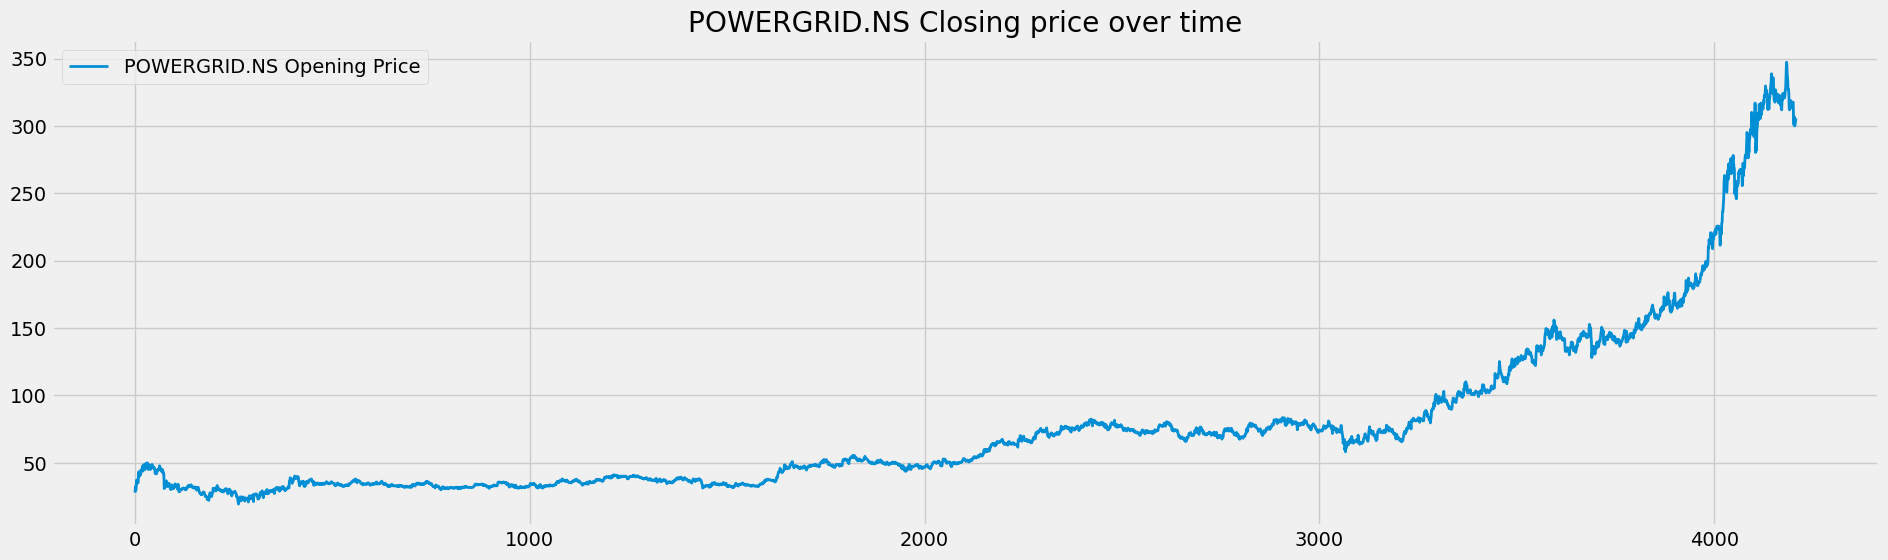

In [27]:
import matplotlib.pyplot as plt


plt.figure(figsize = (21, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 2)
plt.title(f'{stock} Closing price over time')
plt.legend()
plt.show()

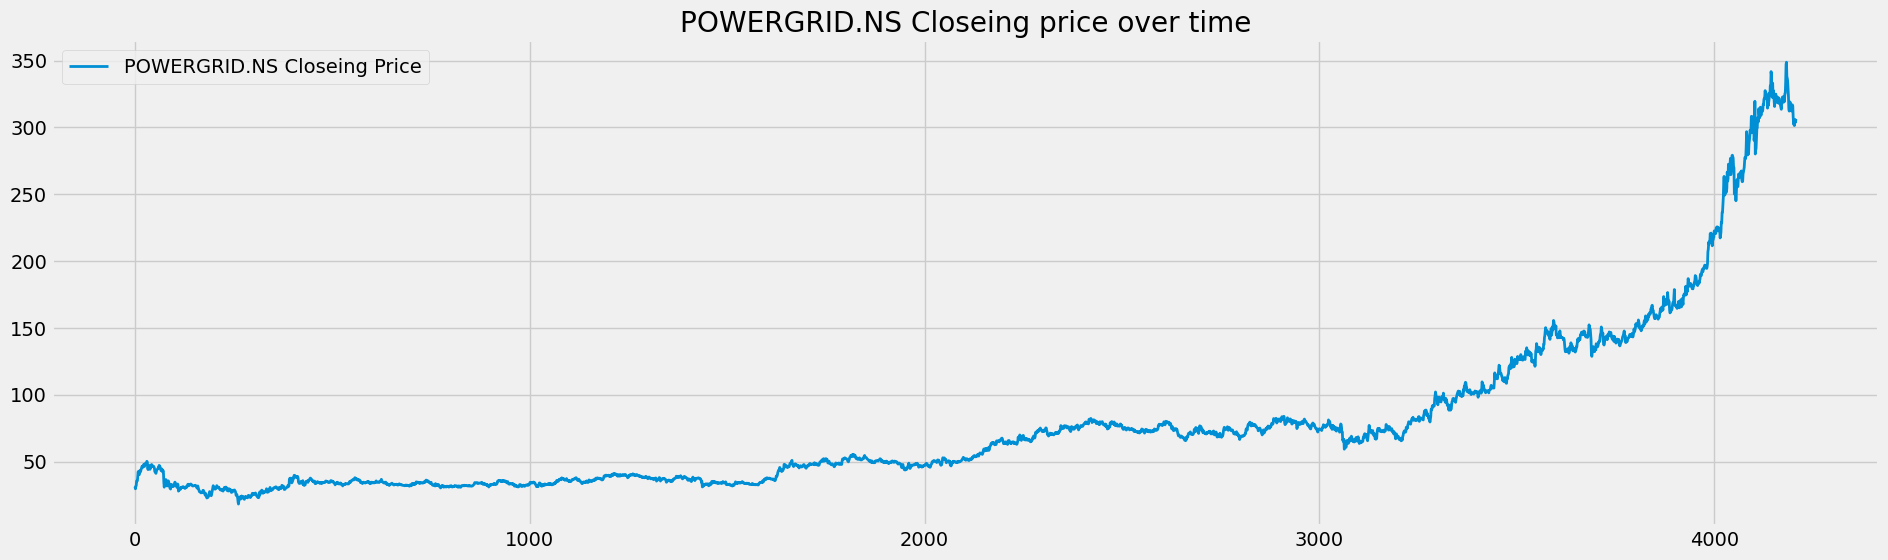

In [28]:
import matplotlib.pyplot as plt


plt.figure(figsize = (21, 6))
plt.plot(df['Close'], label = f'{stock} Closeing Price', linewidth = 2)
plt.title(f'{stock} Closeing price over time')
plt.legend()
plt.show()

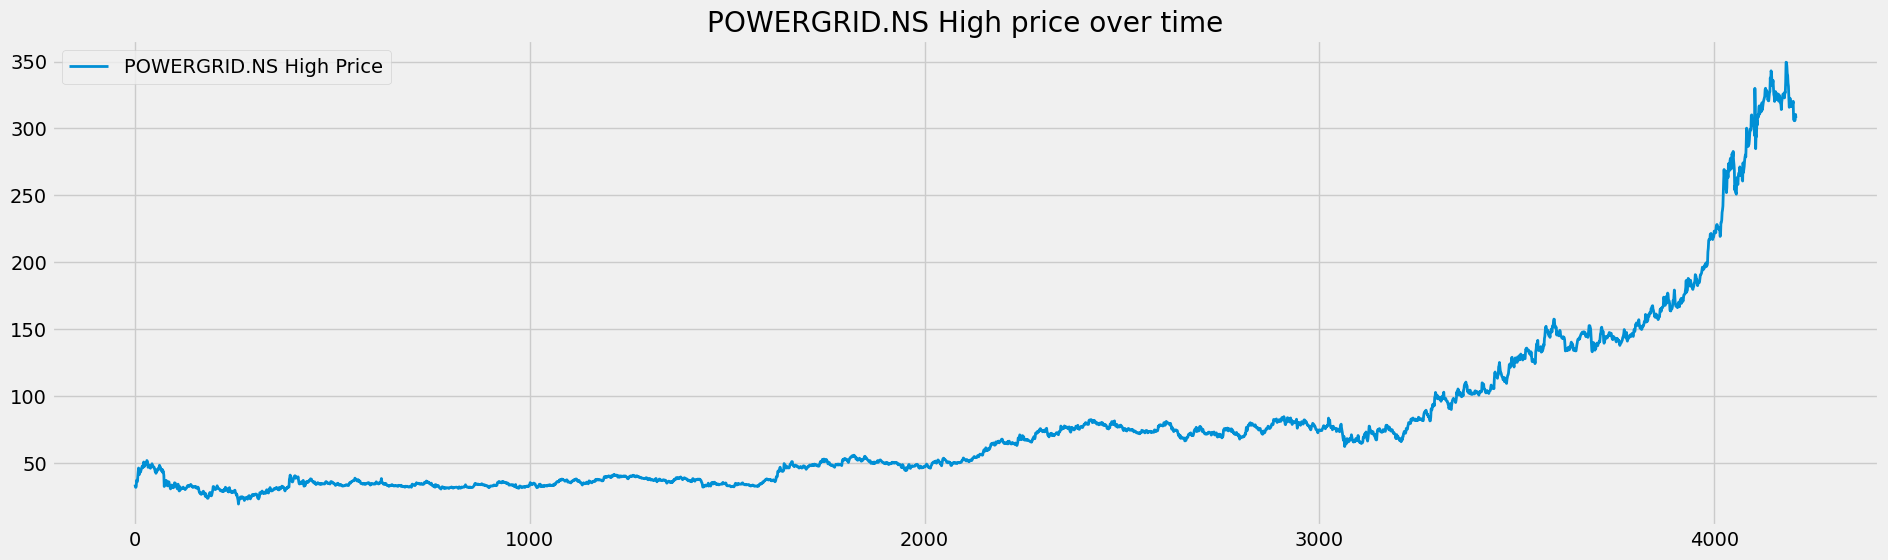

In [29]:
import matplotlib.pyplot as plt


plt.figure(figsize = (21, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 2)
plt.title(f'{stock} High price over time')
plt.legend()
plt.show()

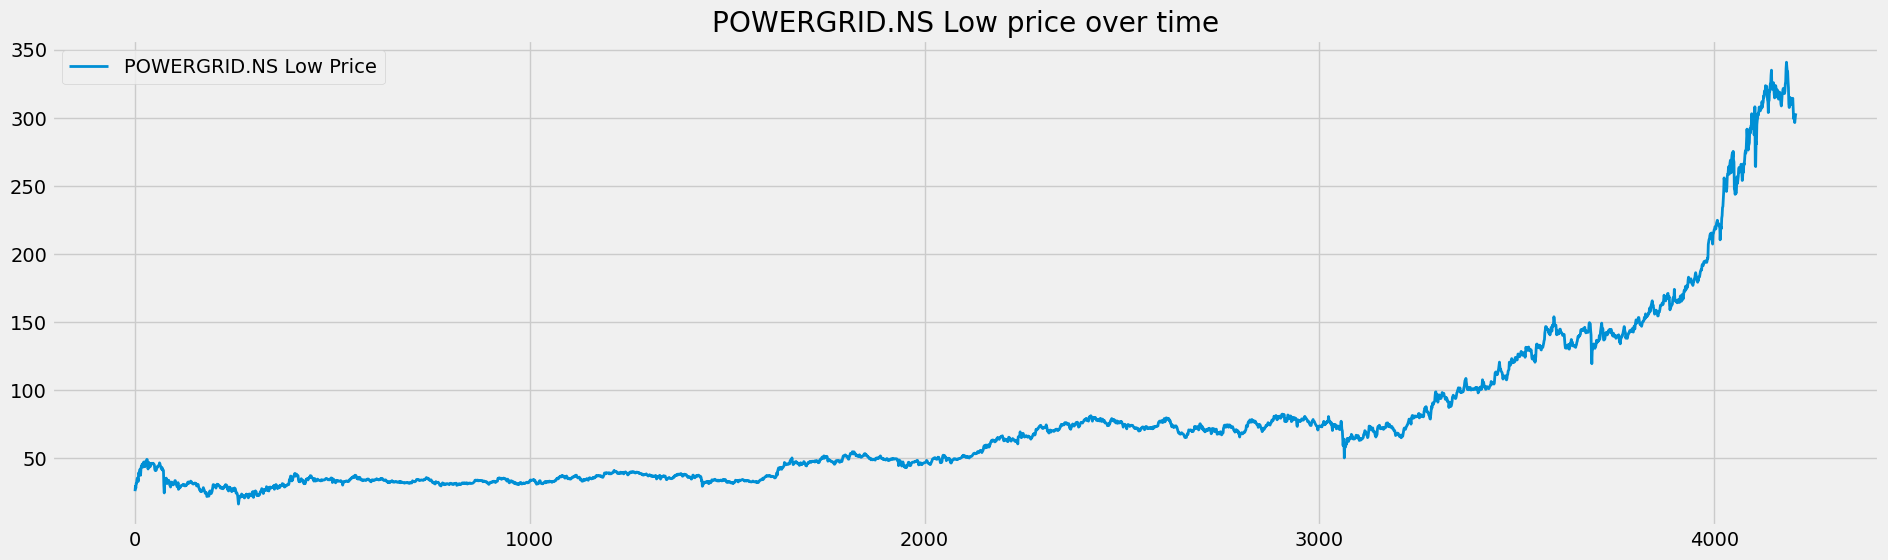

In [30]:
import matplotlib.pyplot as plt


plt.figure(figsize = (21, 6))
plt.plot(df['Low'], label = f'{stock} Low Price', linewidth = 2)
plt.title(f'{stock} Low price over time')
plt.legend()
plt.show()

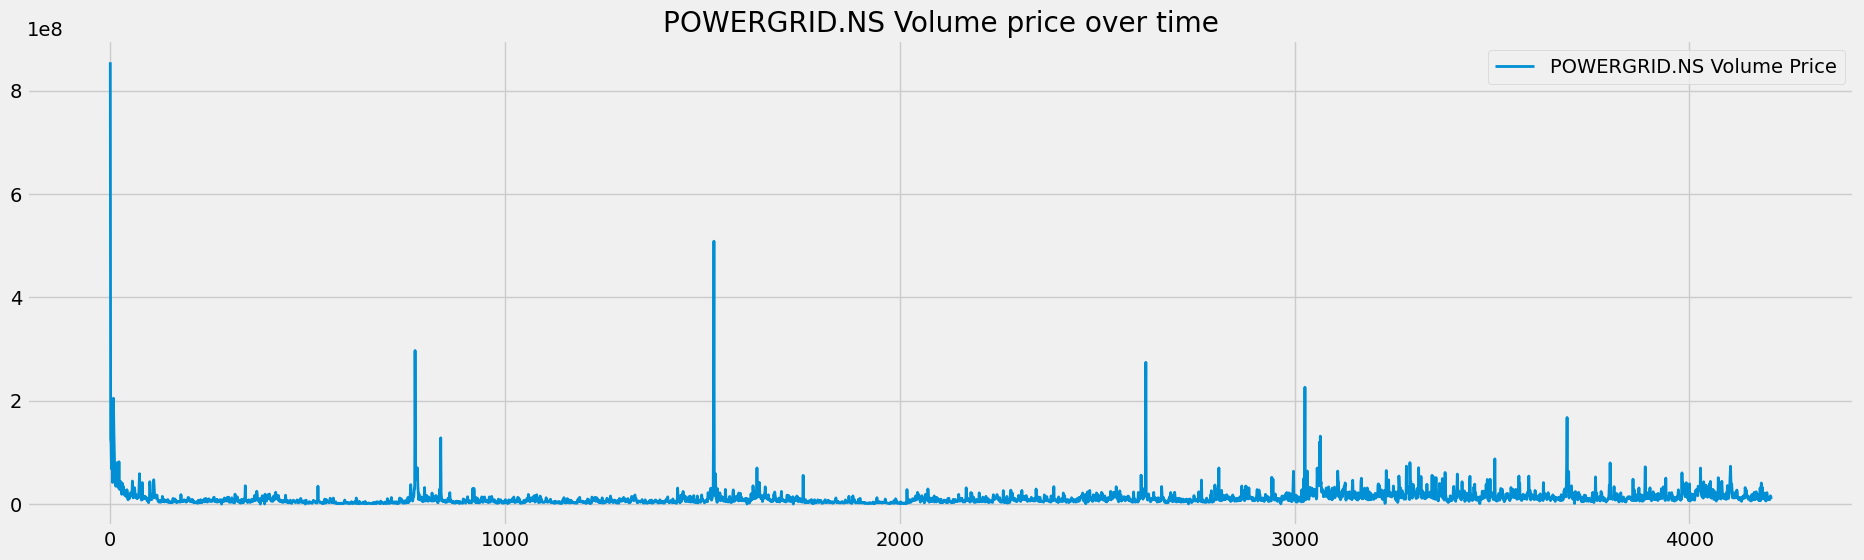

In [31]:
import matplotlib.pyplot as plt


plt.figure(figsize = (21, 6))
plt.plot(df['Volume'], label = f'{stock} Volume Price', linewidth = 2)
plt.title(f'{stock} Volume price over time')
plt.legend()
plt.show()

In [32]:
#Moving Average
# [10,20,30,40,50,60,70,80,90]
# moving average for last 5 days -> null null null null

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[2:7])/5)

50.0


In [33]:
import pandas as pd
df01 = pd.DataFrame(temp_data)

In [34]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [35]:
ma100 = df.Close.rolling(100).mean()

In [36]:
ma200 = df.Close.rolling(200).mean()

In [37]:
# next 30 days stock
# LSTM(Long Short-Term Memory) --- why LSTM
# RNN(Recurrent Neural Networks) --- why Not RNN

ema100 = df.Close.ewm(span = 100, adjust = False).mean()


In [38]:
ema200 = df['Close'].ewm(span = 200, adjust = False).mean()

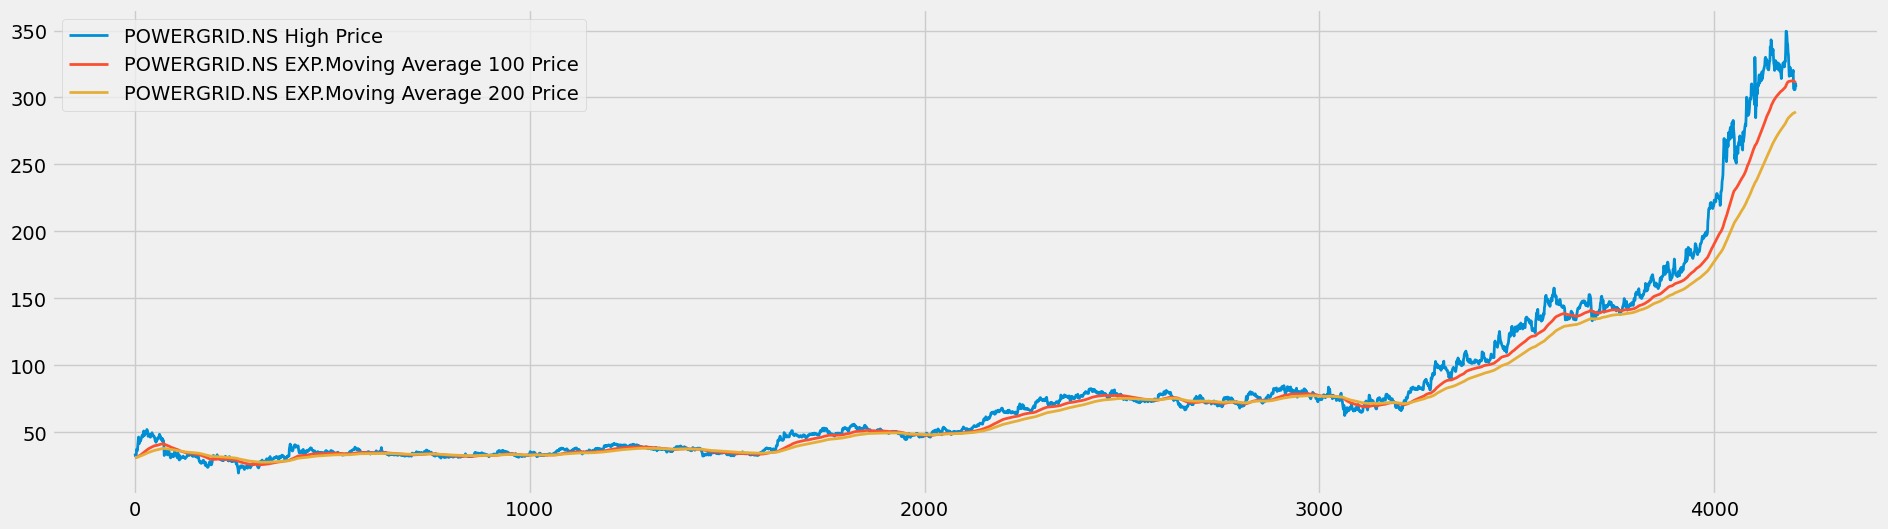

In [39]:
import matplotlib.pyplot as plt


plt.figure(figsize = (21, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 2)
plt.plot(ema100, label = f'{stock} EXP.Moving Average 100 Price', linewidth = 2)
plt.plot(ema200, label = f'{stock} EXP.Moving Average 200 Price', linewidth = 2)
# plt.title(f'{stock} High price over time')
plt.legend()
plt.show()

In [40]:
# Traning and Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])

data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70) : int(len(df))])

In [41]:
data_training.shape

(2945, 1)

In [42]:
data_testing.shape

(1263, 1)

In [43]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0,1))

In [44]:
data_training_array = scaler.fit_transform(data_training)

In [45]:
data_training_array

array([[0.19808585],
       [0.17371826],
       [0.20447384],
       ...,
       [0.90774437],
       [0.86000388],
       [0.8729967 ]])

In [46]:
data_training_array.shape[0]

2945

In [47]:
import numpy as np

x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
   
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)


In [48]:
x_train.shape

(2845, 100, 1)

In [49]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [50]:
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense

model = Sequential()

# Layer 1: input_shape specifies (Time_Steps, Features)
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2
model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

# Layer 3
model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

# Layer 4: LAST LSTM layer must have return_sequences=False
model.add(LSTM(units=120, activation='relu', return_sequences=False)) 
model.add(Dropout(0.5))

# Final Output Layer
model.add(Dense(units=1))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 50)           10400     
                                                                 
 dropout (Dropout)           (None, 100, 50)           0         
                                                                 
 lstm_1 (LSTM)               (None, 100, 60)           26640     
                                                                 
 dropout_1 (Dropout)         (None, 100, 60)           0         
                                                                 
 lstm_2 (LSTM)               (None, 100, 80)           45120     
                                                                 
 dropout_2 (Dropout)         (None, 100, 80)           0         
                                                                 
 lstm_3 (LSTM)               (None, 120)               9

In [51]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train,y_train, epochs = 50)

Epoch 1/50
89/89 [==============================] - 16s 141ms/step - loss: 0.0399
Epoch 2/50
89/89 [==============================] - 16s 178ms/step - loss: 0.0080
Epoch 3/50
89/89 [==============================] - 15s 166ms/step - loss: 0.0070
Epoch 4/50
89/89 [==============================] - 16s 178ms/step - loss: 0.0071
Epoch 5/50
89/89 [==============================] - 14s 162ms/step - loss: 0.0069
Epoch 6/50
89/89 [==============================] - 15s 163ms/step - loss: 0.0059
Epoch 7/50
89/89 [==============================] - 15s 170ms/step - loss: 0.0060
Epoch 8/50
89/89 [==============================] - 15s 165ms/step - loss: 0.0054
Epoch 9/50
89/89 [==============================] - 14s 163ms/step - loss: 0.0055
Epoch 10/50
89/89 [==============================] - 15s 166ms/step - loss: 0.0051
Epoch 11/50
89/89 [==============================] - 15s 168ms/step - loss: 0.0045
Epoch 12/50
89/89 [==============================] - 15s 169ms/step - loss: 0.0039
Epoch 13/50
8

In [52]:
past_100_days = data_training.tail(100)

In [53]:
# 1. Pichle 100 din aur testing data ko combine karein
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

# 2. Sirf 'Close' column (ya jo bhi target hai) select karein
# Note: Humein scaler apply karne se pehle values chahiye hoti hain
input_data = scaler.fit_transform(final_df) 

print(input_data.shape)

(1363, 1)


In [54]:
final_df.head()

Ticker,POWERGRID.NS
0,73.060188
1,74.549614
2,74.804375
3,74.647606
4,75.078743


In [55]:
input_data = scaler.fit_transform(final_df)

In [56]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test  = np.array(x_test), np.array(y_test)

In [57]:
x_test.shape

(1263, 100, 1)

In [58]:
y_predicted = model.predict(x_test)

40/40 [==============================] - 4s 68ms/step


In [59]:
y_predicted.shape

(1263, 1)

In [60]:
scaler.scale_

array([0.00345503])

In [61]:
scaler_factor = 1 / 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

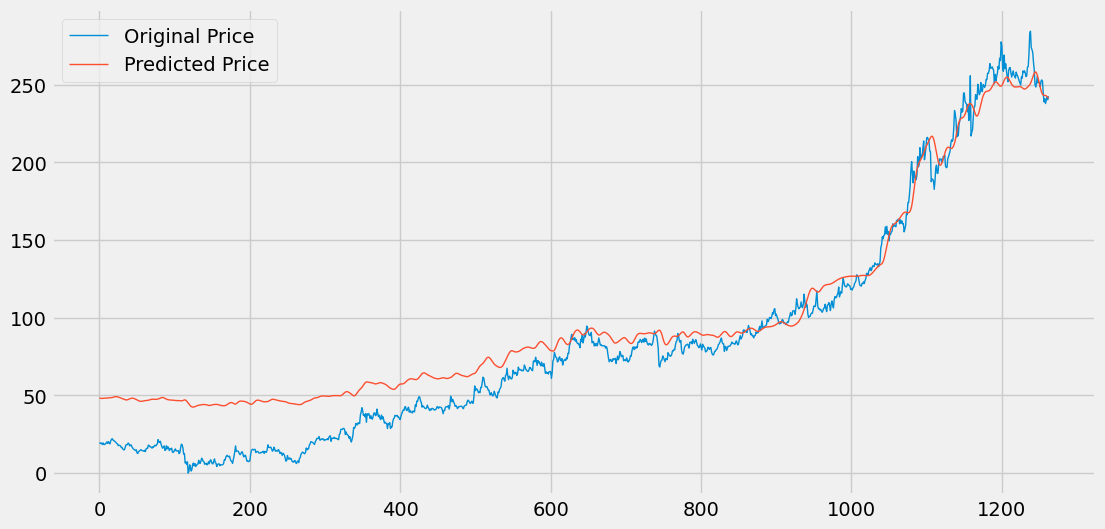

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [65]:
model.save('stock_dl_model.h5')